# Review gp_collab_cernak results

Same structure as DOPE-MURI's `02_review_results.ipynb`, reading runs produced
by this package. Set `RUNS` below to the folder holding the finished tasks. The
first cell exports them into the layout `load_results` reads, then loads them;
nothing here launches training.

Needs `numpy pandas scipy scikit-learn matplotlib` (and `ipywidgets` for the
control panel). **No PyTorch** -- review is CPU-only and model-free.

Put this notebook and `results.py` in the `gp_collab_hazel` folder, next to
`gpc/` and `inputs/`.

In [1]:
from pathlib import Path
import textwrap
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from gpc.results import (prepare, load_results, lolo_report, plot_parity,
                     plot_lolo_comparison, grouped_predictions)

ROOT = Path.cwd().resolve()
RUNS = ROOT / "runs/cernak_v1"
# cernak_v1 is this project's first and only run. Unlike the Perera and Doyle
# projects there are no superseded _oldPCS runs here: pc_scores has meant the
# PC1..PC4 projection since the first fit.

# Builds RUNS/hazel_export/collected the first time; pass refresh=True after
# adding or rerunning tasks. Methods are relabelled to hazel_gp's names
# (iid_stratified_5 -> iid_matched, kfold_stratified_5 -> kfold) so the
# arguments below match the other two reviews. The folds stay
# catalyst-stratified; only the labels change.
EXPORT = prepare(RUNS, bundle=ROOT / "inputs", refresh=False)

tables, collection = load_results(EXPORT)
print("Complete benchmark:", collection["complete"])
print("Completed tasks:", collection["completed_tasks"], "/", collection["expected_tasks"])
display(tables["summary"])

exported 75 fits -> C:\Users\koand\OneDrive\Documents\GitHub\DOPE-MURI\gp_collab_cernak\runs\cernak_v1\hazel_export\collected
in 02_review_results.ipynb set:  RUNS = Path("C:\Users\koand\OneDrive\Documents\GitHub\DOPE-MURI\gp_collab_cernak\runs\cernak_v1\hazel_export")
Complete benchmark: True
Completed tasks: 75 / 75


,model,method,completed_fits,expected_fits,complete_method,run_complete,aggregation,r2,rmse,mae,...,mean_predictive_std,pit_cdf_mae,abs_residual_std_spearman,coverage_50,width_50,coverage_80,width_80,coverage_95,width_95,n_test
0,catalyst_ohe,lolo,5,5,True,True,mean_split_metrics,0.545874,25.296753,17.752250,...,24.859393,0.069971,0.046383,0.630607,33.534812,0.815012,63.717189,0.916209,97.447032,
1,catalyst_ohe,lolo,5,5,True,True,pooled_predictions,0.607773,25.476876,17.614204,...,25.052245,0.046959,0.029148,0.630303,33.794965,0.821212,64.211488,0.921970,98.202997,1320.0
2,catalyst_ohe,iid_matched,5,5,True,True,mean_split_metrics,0.797760,18.235071,11.865317,...,23.266138,0.088228,0.095657,0.755303,31.385544,0.899242,59.633512,0.962879,91.201586,
3,catalyst_ohe,iid_matched,5,5,True,True,pooled_predictions,0.798160,18.275998,11.865317,...,23.266138,0.087438,0.092005,0.755303,31.385544,0.899242,59.633512,0.962879,91.201586,1320.0
4,catalyst_ohe,kfold,5,5,True,True,mean_split_metrics,0.797760,18.235071,11.865317,...,23.266138,0.088228,0.095657,0.755303,31.385544,0.899242,59.633512,0.962879,91.201586,
5,catalyst_ohe,kfold,5,5,True,True,pooled_predictions,0.798160,18.275998,11.865317,...,23.266138,0.087438,0.092005,0.755303,31.385544,0.899242,59.633512,0.962879,91.201586,1320.0
6,selected_2,lolo,5,5,True,True,mean_split_metrics,0.567958,23.453152,17.402713,...,25.128922,0.106165,0.102007,0.628618,33.898400,0.795000,64.408018,0.960952,98.503563,
7,selected_2,lolo,5,5,True,True,pooled_predictions,0.652738,23.972130,16.902954,...,25.252064,0.053669,0.450970,0.639394,34.064517,0.812879,64.723646,0.963636,98.986274,1320.0
8,selected_2,iid_matched,5,5,True,True,mean_split_metrics,0.788599,18.652069,12.003418,...,23.232648,0.087689,0.111826,0.737879,31.340366,0.890909,59.547673,0.954545,91.070308,
9,selected_2,iid_matched,5,5,True,True,pooled_predictions,0.788974,18.687261,12.003418,...,23.232648,0.087198,0.113389,0.737879,31.340366,0.890909,59.547673,0.954545,91.070308,1320.0


### Inspect predictions

Pick a model, method and held-out catalyst; the parity plot and that split's
metrics redraw. Needs `ipywidgets`; skip this cell if it is not installed.

In [2]:
from gpc.results import review_controls

# Parity-plot heading. None keeps the default "Model | method[| ligand]";
# otherwise a str.format template with `model`, `method`, `reference_group`
# fields, e.g. "{model} on {method} ({reference_group})".
TITLE = None
display(review_controls(tables, title=TITLE))

### LOLO reported three ways

`per_ligand` scores each held-out catalyst on its own rows, `mean_across_ligands`
averages those, and `pooled_over_folds` concatenates all eight folds and scores
once. Pooled and averaged values are **not** interchangeable: a per-catalyst R² is
measured against that ligand's own (smaller) variance, so the averaged figure is
systematically harsher.

,model,view,scope,n_test,r2,rmse,mae,kendall_tau
0,catalyst OHE,per_ligand,Aphos G3,441.0,0.6734,23.8420,17.1638,0.6312361693381326
1,catalyst OHE,per_ligand,RuPhos G3,221.0,0.7354,19.9912,14.9023,0.680878648448523
2,catalyst OHE,per_ligand,Xphos G3,217.0,0.5739,26.3064,17.5647,0.6191419497482934
3,catalyst OHE,per_ligand,tBu3P G2,226.0,0.7556,21.1143,14.8661,0.6602724999099806
4,catalyst OHE,per_ligand,tBuXphos G3,215.0,-0.0090,35.2299,24.2645,0.4525794865229716
5,catalyst OHE,mean_across_ligands,5 ligands,NaN,0.5459,25.2968,17.7522,0.608822
6,catalyst OHE,pooled_over_folds,5 folds,1320.0,0.6078,25.4769,17.6142,0.602115
7,selected_2,per_ligand,Aphos G3,441.0,0.7581,20.5178,15.0251,0.6702538544000071
8,selected_2,per_ligand,RuPhos G3,221.0,0.7380,19.8923,12.6257,0.6956497320502028
9,selected_2,per_ligand,Xphos G3,217.0,0.7132,21.5834,13.4518,0.6984369730666388


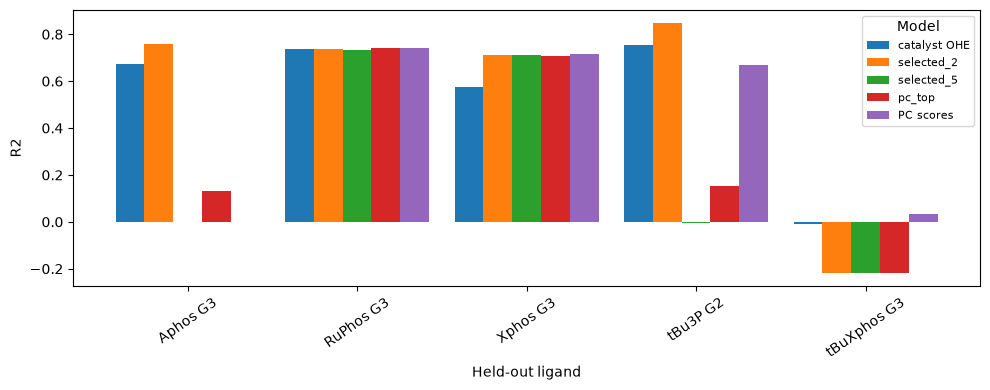

In [3]:
# Start from an empty figure registry. The inline backend re-renders every
# figure still open at the end of a cell, so anything leaked by an earlier
# run of this kernel would be drawn again here on top of this cell's own.
plt.close("all")

METRIC = "r2"
report = lolo_report(tables["predictions"], tables["metrics_by_split"])
display(report[["model", "view", "scope", "n_test", "r2", "rmse", "mae", "kendall_tau"]].round(4))

fig_ligands = plot_lolo_comparison(tables["metrics_by_split"], metric=METRIC)
display(fig_ligands)
plt.close(fig_ligands)

### Compare the three evaluation methods

LOLO against the two in-distribution controls. The stratified 8-fold has LOLO's
exact fold geometry (2688/384) with every ligand present in training, so the gap
between them is the cost of meeting an unseen ligand.

r2                        rmse                  
method       iid_matched   kfold    lolo iid_matched    kfold     lolo
model                                                                 
catalyst_ohe      0.7982  0.7982  0.6078     18.2760  18.2760  25.4769
selected_2        0.7890  0.7890  0.6527     18.6873  18.6873  23.9721
selected_5        0.7887  0.7887  0.2238     18.6984  18.6984  35.8395
pc_top            0.7894  0.7894  0.3009     18.6681  18.6681  34.0126
pc_scores         0.7911  0.7911  0.3830     18.5923  18.5923  31.9524

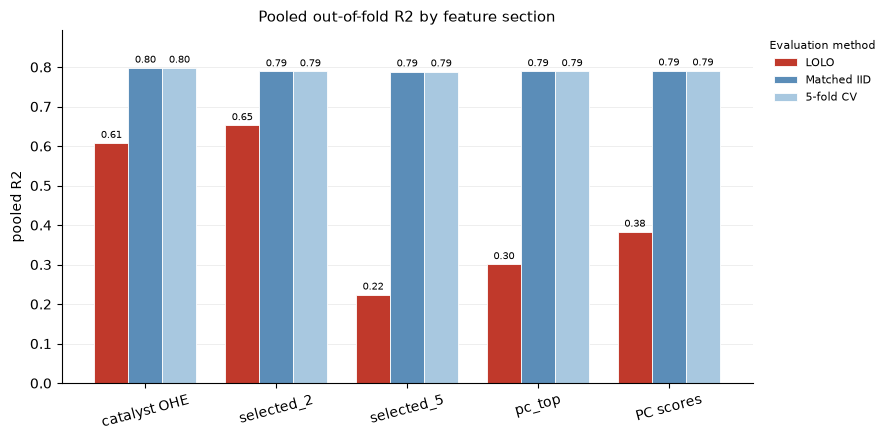

In [6]:
from gpc.results import model_label, method_label, _model_order
# Start from an empty figure registry. The inline backend re-renders every
# figure still open at the end of a cell, so anything leaked by an earlier
# run of this kernel would be drawn again here on top of this cell's own.
plt.close("all")
# WHAT THIS CHART LEAVES OUT. Both omissions are deliberate, and neither costs
# you any numbers: the pivot table above still carries all seven feature
# sections and all four methods.
#
# 1. FEATURE SECTIONS -- the two rxnpredict sets carry Doyle's published DFT
#    descriptors rather than ligand chemistry, so they are not like-for-like
#    with the other five.
#    To draw them, comment the first line and uncomment the second.
EXCLUDE_FROM_CHART = ["rxnpredict_full", "rxnpredict_full_ohe"]
# EXCLUDE_FROM_CHART = []          # <- all seven feature sections
#
# 2. METHODS -- kfold_5 is the UNSTRATIFIED 5-fold, and it is dropped here as
#    well. It exists to be read against kfold_stratified_5 ("5-fold CV" in the
#    legend, which IS stratified) in the table above; putting it in would add a
#    fourth bar to every group for a contrast this chart is not about.
#    To draw it, add "kfold_5" to the tuple below.
CHART_METHODS = ("lolo", "iid_matched", "kfold")

summary = tables["summary"]
pooled = summary[summary.aggregation == "pooled_predictions"]
# One canonical model order (gpc.results.MODEL_ORDER) for the table and the
# chart, and the same one in the hazel and cernak reviews, so the two
# read left-to-right identically. pivot() alone would sort alphabetically.
order = _model_order(pooled)
display(pooled.pivot(index="model", columns="method", values=["r2", "rmse"])
              .reindex(order).round(4))

# Grouped bars, not a line. The x axis is five unrelated feature sets, so a line
# joining them would imply an ordering and a continuum that do not exist; bars
# also match plot_lolo_comparison above. Heights are the POOLED figures, so they
# do not equal the mean of that model's per-fold bars in the LOLO chart.
chart_order = [m for m in order if m not in EXCLUDE_FROM_CHART]

table = pooled.pivot(index="model", columns="method", values=METRIC)
table = table.reindex(index=chart_order)          # canonical order, minus the exclusions
table = table[[m for m in CHART_METHODS if m in table.columns]]
table.index = [model_label(m) for m in table.index]
table.columns = [method_label(m) for m in table.columns]

unit = " (% yield)" if METRIC in ("rmse", "mae") else ""
ax = table.plot.bar(figsize=(9, 4.5), width=0.78, edgecolor="white", linewidth=0.6,
                    color=["#c0392b", "#5b8db8", "#a8c8e0"])
ax.set(xlabel="", ylabel=f"pooled {METRIC.upper()}{unit}")
ax.set_ylim(0, table.to_numpy().max() * 1.12)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Evaluation method", fontsize=8, title_fontsize=8, frameon=False,
          loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set_title(f"Pooled out-of-fold {METRIC.upper()} by feature section", fontsize=11)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)

fig_methods = ax.figure
fig_methods.tight_layout()
display(fig_methods)
plt.close(fig_methods)

In [5]:
grouped_iid = grouped_predictions(tables["predictions"], model="selected_2", method="iid_matched")
print("Reference groups:", list(grouped_iid))
# The stratified 8-fold is a single non-repeating partition with every ligand in
# every fold, so it has no per-catalyst reference group and returns one group keyed
# "". Use method="lolo" to get the eight held-out catalysts instead:
grouped_lolo = grouped_predictions(tables["predictions"], model="selected_2", method="lolo")
print("LOLO groups:", list(grouped_lolo))
# grouped_lolo["SPhos"]["y_pred"] is a list of arrays, one per split.

Reference groups: ['']
LOLO groups: ['Aphos G3', 'RuPhos G3', 'Xphos G3', 'tBu3P G2', 'tBuXphos G3']


### Feature importance (ARD)

Needs a task fitted with `"ard": true` under `"gp"` in the run config. With the
isotropic default the GP learns a single lengthscale for the whole feature
vector, so there is nothing per-feature to rank; the cell below then prints the
message naming the task to re-run, and the notebook carries on.

`relevance` is `1 / lengthscale`. An RBF varies fastest along its shortest
lengthscales, so a short lengthscale -- a large relevance -- means the fit leans
on that column, and a feature the GP hands a **huge lengthscale has effectively
been switched off**: the kernel barely changes as that column moves. This ranks
columns within one fit and nothing further. It is not a significance test,
relevances from different models or kernels share no scale, and standardized
descriptors sit on a different input scale from raw 0/1 one-hots, so read the
ranking within a family rather than straight down the whole chart.

Whiskers are the fold quartiles: a long whisker means the folds disagree and
that part of the ranking is soft. Under LOLO a ligand one-hot only exists in the
folds where that ligand was in training -- each fold drops the held-out catalyst's
column -- so `catalyst_ohe`'s one-hots are scored on **three of the four folds**
and their labels say so. That lower fold count is expected, not a bug, but it
does mean their medians are not measured over the same folds as their
neighbours'.

In [ ]:
from gpc.results import rank_features, plot_feature_importance
# Start from an empty figure registry. The inline backend re-renders every
# figure still open at the end of a cell, so anything leaked by an earlier
# run of this kernel would be drawn again here on top of this cell's own.
plt.close("all")

BUNDLE = ROOT / "inputs"          # the prepared inputs cell 1 passed to prepare()

IMPORTANCE_MODEL = "selected_5"
LIGAND_ONLY      = True     # True -> ligand descriptors only; False -> every encoded feature
TOP_N            = 20

# LIGAND_ONLY = False also ranks the reaction-condition one-hots (aryl halide,
# base, additive). They outnumber the ligand columns several times over, so the
# chart gets long; TOP_N still truncates it, and `ranked` holds the full table.
fig_importance = None
try:
    ranked = rank_features(RUNS, BUNDLE, IMPORTANCE_MODEL,
                           method="lolo", ligand_only=LIGAND_ONLY, top=TOP_N)
    display(ranked.round(4))
    fig_importance = plot_feature_importance(RUNS, BUNDLE, IMPORTANCE_MODEL,
                                             method="lolo", ligand_only=LIGAND_ONLY,
                                             top=TOP_N)
    display(fig_importance)
    plt.close(fig_importance)
except (ValueError, FileNotFoundError) as error:
    # Reported, not raised: nothing below this section depends on it.
    print(f"No per-feature relevance for {IMPORTANCE_MODEL}:\n")
    print(textwrap.fill(str(error), 88, initial_indent="  ", subsequent_indent="  "))

In [ ]:
# Every model at once, ligand features only, so the toggle above does not have
# to be edited once per model just to compare them.
SUMMARY_TOP = 5
# ---------------------------------------------------------------------------
# FEATURE SECTIONS -- the two cernak sets carry Doyle's published DFT
# descriptors rather than ligand chemistry, and they are disabled in
# configs/default.json for this run, so they are left out of the loop too.
# To include them, comment the first line and uncomment the second.
EXCLUDE_FROM_SUMMARY = ["cernak_full", "cernak_full_ohe"]
# EXCLUDE_FROM_SUMMARY = []        # <- every feature section present in RUNS
# ---------------------------------------------------------------------------
SUMMARY_MODELS = [m for m in _model_order(tables["summary"])
                  if m not in EXCLUDE_FROM_SUMMARY]

parts, skipped = [], []
for model in SUMMARY_MODELS:
    try:
        part = rank_features(RUNS, BUNDLE, model, method="lolo",
                             ligand_only=True, top=SUMMARY_TOP)
    except (ValueError, FileNotFoundError) as error:
        skipped.append((model, str(error)))
        continue
    part.insert(0, "model", model)
    parts.append(part[["model", "feature", "median_relevance", "relevance_q1",
                       "relevance_q3", "folds", "n_folds"]])

if parts:
    # Read the ORDER within a model's own block, not one model's numbers against
    # another's: each model encodes a different vector, so its lengthscales --
    # and the relevances built from them -- carry their own scale.
    display(pd.concat(parts, ignore_index=True).round(4))
if skipped:
    # The first message in full -- it names the fix -- then the leading clause of
    # each of the others, which is enough to see whether they failed for the same
    # reason without five near-identical paragraphs of output.
    print(f"{len(skipped)} of {len(SUMMARY_MODELS)} models have no per-feature "
          f"lengthscales to rank:\n")
    for position, (model, message) in enumerate(skipped):
        text = message if position == 0 else message.split(" -- ")[0]
        print(textwrap.fill(text, 88, initial_indent=f"  {model}: ",
                            subsequent_indent="    ") + "\n")

### Performance vs train/test distance in feature space

Under LOLO every fold holds out one catalyst, so each point below is one catalyst:
how far it sat from the ligands the GP was trained on, against how well that
fold scored. Distance is Euclidean in standardized ligand-descriptor space,
using the **training fold's scaler only** -- the held-out catalyst contributes
nothing to the fit that defines the space, so the distance leaks nothing into
the score it is plotted against. Reaction conditions are left out: every ligand
is run over the same grid, so including them would measure the design rather
than the chemistry.

Two definitions are drawn side by side. `centroid_distance` is to the mean of
the training ligands; `nearest_distance` is to the closest single one, usually
the better read on extrapolation, because a ligand can sit near the training
mean while resembling nothing actually trained on.

Four ligands here (eight in the hazel review) means four points, so Spearman's
rho is **suggestive, not conclusive** -- at n = 4 a perfect +/-1 is cheap, and
one catalyst moves it. Read the sign against the metric: for `rmse` or `mae`,
positive rho is the expected "farther is worse"; for `r2` or `kendall_tau` it is
negative rho. `catalyst_ohe` is refused rather than plotted, because a one-hot
ligand block places every ligand exactly the same distance apart, so it has no
descriptor geometry to measure and the numbers would be noise.

In [ ]:
from gpc.results import distance_vs_performance, plot_distance_vs_performance
# Start from an empty figure registry. The inline backend re-renders every
# figure still open at the end of a cell, so anything leaked by an earlier
# run of this kernel would be drawn again here on top of this cell's own.
plt.close("all")

BUNDLE = ROOT / "inputs"          # the prepared inputs cell 1 passed to prepare()

DISTANCE_MODEL  = "selected_5"    # a descriptor model: selected_2, selected_5, pc_top, pc_scores
DISTANCE_METRIC = "rmse"          # the column joined from metrics_by_split

fig_distance = None
try:
    distances = distance_vs_performance(RUNS, BUNDLE, DISTANCE_MODEL,
                                        method="lolo", metric=DISTANCE_METRIC)
    display(distances.round(4))
    # Both correlations describe the whole table, so they are carried in .attrs
    # rather than as one constant repeated down every row.
    for key in ("centroid", "nearest"):
        rho, p = distances.attrs["spearman"][key]
        print(f"{key:>8} distance vs {DISTANCE_METRIC}: Spearman rho = "
              + ("n/a" if rho is None else f"{rho:+.3f}  (p = {p:.3f})"))

    # The plot builds the same table again, so prepare()'s "using the existing
    # export" line is printed twice; the numbers are the ones above either way.
    fig_distance = plot_distance_vs_performance(RUNS, BUNDLE, DISTANCE_MODEL,
                                                method="lolo", metric=DISTANCE_METRIC)
    display(fig_distance)
    plt.close(fig_distance)
except (ValueError, FileNotFoundError) as error:
    # Reported, not raised: nothing below this section depends on it.
    print(f"No distance geometry for {DISTANCE_MODEL}:\n")
    print(textwrap.fill(str(error), 88, initial_indent="  ", subsequent_indent="  "))

### Final export

Nothing is written until `SAVE = True`.

In [ ]:
SAVE = False
EXPORT_DIR = ROOT / "exports/local_review_v1"
FIGURE_FORMATS = ["png", "pdf"]
TABLES_TO_SAVE = ["summary", "metrics_by_split", "predictions"]

if SAVE:
    EXPORT_DIR.mkdir(parents=True, exist_ok=False)
    for name in TABLES_TO_SAVE:
        tables[name].to_csv(EXPORT_DIR / f"{name}.csv", index=False)
    report.to_csv(EXPORT_DIR / "lolo_report.csv", index=False)
    # The ARD and distance figures are optional: fig_importance is None when
    # the run was fitted isotropically, and either name is missing entirely if
    # its section was never run, so neither can break the export.
    figures = {"lolo_by_ligand": fig_ligands, "method_comparison": fig_methods,
               "feature_importance": globals().get("fig_importance"),
               "distance_vs_performance": globals().get("fig_distance")}
    figures = {name: fig for name, fig in figures.items() if fig is not None}
    for name, fig in figures.items():
        for fmt in FIGURE_FORMATS:
            fig.savefig(EXPORT_DIR / f"{name}.{fmt}", dpi=300, bbox_inches="tight")
    print("Saved:", EXPORT_DIR)
else:
    print("Preview only. Set SAVE=True when ready.")